# Jerome Avenue rezoning — buildings built, from the Housing Database

**Self-contained.** Every library and every function this notebook uses is defined in it.
The only external inputs are three local files and two NYC Open Data endpoints.

This is the **HousingDB-first** companion to `jerome_ave_bins.ipynb`. Same corridor, same
BIN grain, opposite direction of travel — and it exists because the earlier notebook
answers "what stands on these lots today?" when the question is "what got **built**, and
**when**?"

The earlier pipeline is PLUTO-first: a rezoning BBL list drives a PLUTO lookup, PLUTO
supplies the attributes and unit counts, and DCP's Housing Database is bolted on at the end
as a cross-check. For a construction-timing question that is backwards. PLUTO `unitsres` is
a **lot**-level number — it has to be de-duplicated or it double-counts every multi-building
lot — it carries **no completion date at all**, and its `yearbuilt` is the assessor's current
state rather than a record of construction.

So here the Housing Database is the spine and PLUTO is demoted to two supporting roles: the
**sunsetting audit** (§4) and an independent **`yearbuilt`** to check the completion year
against (§7).

    input BBLs -> resolve to real lots (PLUTO) -> MAP THEM  <- sanity check, before anything else
               -> scope HousingDB to those lots/blocks -> BBL sunsetting audit
               -> one row per BIN (+ demolitions) -> OTI polygon by BIN, lat/long where none
               -> three construction dates side by side
               -> units + buildings by completion year -> chart -> map -> CSVs

**Inputs**

| file | what it is |
|---|---|
| `../data/raw/jerome_rezone_db.csv` | the Admin Code appendix — 188 mapped lots on 27 tax blocks |
| `../data/raw/HousingDB_post2010.csv` | DCP Housing Database, every DOB housing job since 2010 |
| `../data/raw/community_districts_5crt-au7u.csv` | community-district polygons, for the map basemap |

**Outputs** — every table below is written to CSV as it is produced, so each step can be
inspected on its own rather than only through what survives into the final table.

---
## Toolbox — everything this notebook needs

This notebook is **self-contained**: every library it uses is imported below and every
function it calls is defined below. There is no project module to install, no sibling
file to keep in sync — copy the notebook somewhere else with the two local CSVs and it
runs. (The `*_bins` notebooks share a `nycbldg.py`; these deliberately do not.)

The cost of that is real and worth naming: the same toolbox appears in the Jerome Avenue
and East New York notebooks, so a fix to one has to be made in the other. The functions
are grouped into six cells by what they touch — Socrata, PLUTO, HousingDB, footprints,
aggregation, and charts — so the two copies can be diffed cell by cell.

In [1]:
import math
import time
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import requests
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)

### Toolbox 1/6 — Socrata
Anonymous access on purpose. The `SOCRATA_API_KEY` in `.env` is a Socrata *API key*, not
an *app token*; sending it as `X-App-Token` returns 403, and anonymous requests are not
rate-limited enough to matter at this volume.

One pooled session for the whole run, because a few hundred sequential requests with a
fresh TLS handshake each is both slow and the thing Socrata drops first. `soda` retries
connection resets, timeouts and 5xx/429 — none of which mean the query is wrong.

In [2]:
DOMAIN = "data.cityofnewyork.us"
DATASETS = {
    "pluto": "64uk-42ks",        # MapPLUTO — current lot attributes
    "footprints": "5zhs-2jue",   # OTI Building Footprints — current
}
RETRIES, BACKOFF = 4, 3.0

SESSION = requests.Session()
SESSION.headers["User-Agent"] = "fable_housing/hdb rezoning notebook"


def soda(dataset_id, params, retries=RETRIES):
    """One SoQL query against NYC Open Data, returned as a DataFrame."""
    url = f"https://{DOMAIN}/resource/{dataset_id}.json"
    for attempt in range(retries):
        try:
            r = SESSION.get(url, params=params, timeout=300)
            if r.status_code in (429, 500, 502, 503, 504):
                raise requests.HTTPError(f"{r.status_code} from Socrata", response=r)
            r.raise_for_status()
            return pd.DataFrame(r.json())
        except (requests.ConnectionError, requests.Timeout, requests.HTTPError) as e:
            if attempt == retries - 1:
                raise
            wait = BACKOFF * (2 ** attempt)
            print(f"  socrata {dataset_id}: {type(e).__name__}, retry "
                  f"{attempt + 1}/{retries - 1} in {wait:.0f}s")
            time.sleep(wait)


def soda_in(dataset_id, select, field, values, batch=250, extra=None):
    """`field in (values)`, chunked so a long IN-clause never blows the URL length limit."""
    values = [v for v in dict.fromkeys(values) if v and v == v]
    out = []
    for i in range(0, len(values), batch):
        body = "'" + "','".join(values[i:i + batch]) + "'"
        where = f"{field} in ({body})"
        if extra:
            where = f"{extra} AND {where}"
        df = soda(dataset_id, {"$select": select, "$where": where, "$limit": "200000"})
        if len(df):
            out.append(df)
    return pd.concat(out, ignore_index=True) if out else pd.DataFrame()


def bbl_str(s):
    """Socrata returns BBLs float-formatted (`3039500047.00000000`) — keep them 10-char strings.

    A 10-digit BBL cast to float loses its identity, so BBLs are strings everywhere in
    this notebook, start to finish.
    """
    return s.astype(str).str.split(".").str[0]


def is_block_bbl(bbl):
    """A BBL whose lot part is `0000` is a whole tax block, not a real lot."""
    return bbl.endswith("0000")

### Toolbox 2/6 — PLUTO
Two jobs only. `resolve_inputs` turns the raw BBL list into a table of real lots **with
coordinates**, which is what the early sanity map draws; `bbl_status` is the sunsetting
audit.

A block-level BBL (lot `0000`) is not a lot — there is nothing to look up and nothing to
un-merge — so the resolution is to **enumerate every current lot on that tax block**.
That is also why `latitude`/`longitude` are pulled here rather than later: one query
gives both the map and, further down, PLUTO's `yearbuilt` as an independent check on the
HousingDB completion year.

In [3]:
PLUTO_COLS = ("bbl,address,bldgclass,landuse,yearbuilt,unitsres,unitstotal,numbldgs,"
              "assesstot,latitude,longitude")
PLUTO_NUM = ["yearbuilt", "unitsres", "unitstotal", "numbldgs", "assesstot",
             "latitude", "longitude"]


def _pluto_clean(p, source):
    if not len(p):
        return pd.DataFrame(columns=PLUTO_COLS.split(",") + ["source"])
    p = p.copy()
    p["bbl"] = bbl_str(p["bbl"])
    for c in PLUTO_NUM:
        if c in p:
            p[c] = pd.to_numeric(p[c], errors="coerce")
    p["source"] = source
    return p


def resolve_inputs(bbls, boro_code, batch=200):
    """
    Turn a raw BBL list into the real lots it refers to, with coordinates.

    Individual lots are looked up directly. Block-level BBLs (`...0000`) are **expanded**:
    every current lot on that tax block is pulled, because a block reference is a
    statement about a whole block, not a lot that can be looked up.

    `source` separates the two so the map and every count downstream can keep them apart —
    a listed lot is a parcel someone named, a block-expanded lot is its context.

    Returns `(lots, missing)` — the resolved lot table and the individually listed BBLs
    that current PLUTO does not have (retired lots; `bbl_status` chases those).
    """
    lot_bbls = sorted({b for b in bbls if not is_block_bbl(b)})
    block_bbls = sorted({b for b in bbls if is_block_bbl(b)})

    listed = _pluto_clean(soda_in(DATASETS["pluto"], PLUTO_COLS, "bbl", lot_bbls,
                                  batch=400), "listed lot")
    missing = sorted(set(lot_bbls) - set(listed["bbl"]))

    blocks = sorted({int(b[1:6]) for b in block_bbls})
    parts = []
    for i in range(0, len(blocks), batch):
        sub = ",".join(str(x) for x in blocks[i:i + batch])
        chunk = soda(DATASETS["pluto"], {
            "$select": PLUTO_COLS,
            "$where": f"borough='{boro_code}' AND block in ({sub})",
            "$limit": "500000"})
        if len(chunk):
            parts.append(chunk)
    expanded = _pluto_clean(
        pd.concat(parts, ignore_index=True) if parts else pd.DataFrame(), "on a listed block")

    # a lot that is both individually listed and on a listed block counts as listed
    lots = (pd.concat([listed, expanded], ignore_index=True)
              .drop_duplicates("bbl", keep="first").reset_index(drop=True))

    print(f"input BBLs: {len(set(bbls))} | individual lots {len(lot_bbls)} "
          f"| block-level (lot 0000) {len(block_bbls)}")
    print(f"  listed lots found in PLUTO: {len(listed)} of {len(lot_bbls)}"
          f" | not in PLUTO (retired): {len(missing)}")
    print(f"  {len(blocks)} tax blocks -> {len(expanded)} lots enumerated")
    print(f"  resolved lots: {len(lots)} | {lots['source'].value_counts().to_dict()}")
    print(f"  with coordinates: {int(lots['latitude'].notna().sum())} of {len(lots)}")
    return lots, missing


def appbbl_successors(bbls, batch=250):
    """
    Current PLUTO lots created **out of** one of `bbls` — the forward lineage.

    `APPBBL` sits on the *successor* row and points back at the retired predecessor, so
    the query is "which current lot declares one of ours as its `appbbl`?".

    The filter that makes this usable: PLUTO fills `appbbl` with a lot's **own** BBL when
    nothing was apportioned. Left in, every lot comes back as a successor of itself.
    """
    succ = soda_in(DATASETS["pluto"], PLUTO_COLS + ",appbbl,appdate", "appbbl", bbls,
                   batch=batch)
    if not len(succ):
        print("APPBBL successors: 0")
        return pd.DataFrame(columns=PLUTO_COLS.split(",") + ["appbbl", "appdate"])
    succ["bbl"], succ["appbbl"] = bbl_str(succ["bbl"]), bbl_str(succ["appbbl"])
    n_raw = len(succ)
    succ = succ[succ["appbbl"].isin(bbls) & (succ["appbbl"] != succ["bbl"])]
    print(f"APPBBL successors: {len(succ)} genuine "
          f"({n_raw - len(succ)} self-references dropped, appbbl == bbl)")
    return succ.reset_index(drop=True)


def bbl_status(bbls):
    """
    The sunsetting audit: is each BBL still a live lot in current PLUTO?

    A **sunsetted** BBL is one DOF has retired — split, merged, or converted to a condo —
    so it no longer appears in PLUTO. For those, and only those, we follow the
    apportionment lineage above. The answer lands in a **new** column,
    `pluto_current_bbl`, equal to `bbl` when the lot is live. **Nothing is overwritten**,
    least of all a BIN: every join downstream is keyed on BIN, so whatever DOF did to the
    lot underneath, the building keeps its identity.

    Guards, because a wrong value that looks authoritative is worse than a blank: a
    predecessor with more than one successor is left unfilled rather than guessed at, and
    a successor on a different tax block is reported as suspect (an apportionment does not
    move a lot to another block).
    """
    bbls = sorted({b for b in bbls if b})
    live = soda_in(DATASETS["pluto"], "bbl", "bbl", bbls, batch=400)
    live = set(bbl_str(live["bbl"])) if len(live) else set()
    missing = [b for b in bbls if b not in live]

    out = pd.DataFrame({"bbl": bbls})
    out["in_current_pluto"] = out["bbl"].isin(live)
    out["pluto_current_bbl"] = out["bbl"]
    out["successor_source"] = pd.NA

    if missing:
        succ = appbbl_successors(missing)
        if len(succ):
            n = succ.groupby("appbbl")["bbl"].nunique()
            fills = {}
            for old, grp in succ.groupby("appbbl"):
                if n[old] > 1:
                    print(f"  skip {old}: {n[old]} successors — ambiguous, left unfilled")
                    continue
                new = grp["bbl"].iloc[0]
                if new[:6] != old[:6]:
                    print(f"  SUSPECT {old} -> {new}: successor is on a different tax block")
                fills[old] = new
            if fills:
                hit = out["bbl"].isin(fills)
                out.loc[hit, "pluto_current_bbl"] = out.loc[hit, "bbl"].map(fills)
                out.loc[hit, "successor_source"] = "pluto_appbbl"

    out["bbl_sunsetted"] = ~out["in_current_pluto"]
    n_gone = int(out["bbl_sunsetted"].sum())
    print(f"BBL sunsetting audit: {n_gone} of {len(out)} not in current PLUTO"
          f" | successor found for {int(out['successor_source'].notna().sum())}")
    if n_gone:
        print(out[out["bbl_sunsetted"]].to_string(index=False))
    else:
        print("  -> nothing sunsetted; pluto_current_bbl == bbl on every row")
    return out

### Toolbox 3/6 — the DOB/DCP Housing Database
`HousingDB_post2010.csv` is DCP's curated record of every DOB housing job since 2010
(81,708 rows, version 25Q4). It is the spine of this notebook because it is **per job** —
already the unit of construction — and it carries the completion date and the net unit
change that PLUTO cannot supply.

Read as **strings**: `BBL` is 10 digits and `BIN` is 7, and either becomes garbage as a
float. `Job_Desc` is quoted free text full of commas, so it needs a real CSV parser.

`hdb_scope` cuts the file down to a study area. The tax block is the **first six**
characters of the BBL (borough + 5-digit block); cutting to seven includes the first
digit of the lot and matches almost nothing.

In [4]:
HDB_KEEP = ["Job_Number", "Job_Type", "Job_Status", "BIN", "BBL", "Boro", "AddressNum",
            "AddressSt", "CompltYear", "PermitYear", "ClassAInit", "ClassAProp",
            "ClassANet", "Units_CO", "DateFiled", "DatePermit", "DateComplt",
            "Bldg_Class", "Job_Desc", "Latitude", "Longitude"]
HDB_NUM = ["CompltYear", "PermitYear", "ClassAInit", "ClassAProp", "ClassANet",
           "Units_CO", "Latitude", "Longitude"]


def load_housingdb(path):
    """Load the Housing Database, typed and with the two derived columns everything uses."""
    hdb = pd.read_csv(path, dtype=str, low_memory=False)
    absent = [c for c in HDB_KEEP if c not in hdb.columns]
    if absent:
        raise ValueError(f"HousingDB is missing expected columns: {absent}")
    hdb = hdb[HDB_KEEP].copy()
    for c in HDB_NUM:
        hdb[c] = pd.to_numeric(hdb[c], errors="coerce")
    hdb["BBL"] = hdb["BBL"].fillna("").str.strip()
    hdb["BIN"] = hdb["BIN"].fillna("").str.strip()
    # Job_Status is an ordered string ('5. Completed Construction'); 4 = partially complete
    hdb["hdb_completed"] = hdb["Job_Status"].str[0].isin(["4", "5"])
    hdb["hdb_address"] = (hdb["AddressNum"].fillna("") + " "
                          + hdb["AddressSt"].fillna("")).str.strip()
    print("HousingDB rows:", len(hdb), "| distinct BBL:", hdb["BBL"].nunique(),
          "| distinct BIN:", hdb["BIN"].nunique(), "| completed:",
          int(hdb["hdb_completed"].sum()))
    return hdb


def hdb_scope(hdb, bbls):
    """
    Cut the Housing Database down to a study area, by exact BBL and by tax block.

    `scope_via = "bbl"` is a job filed under one of the individually listed lots;
    `"bbl_block"` is a job on a lot sitting on one of the listed `0000` blocks. Both rungs
    are needed and the split is usually lopsided — the jobs on a listed block are filed
    under the individual lot BBLs that block contains, so without the block rung most of a
    block-listed study area is invisible.
    """
    lot_set = {b for b in bbls if not is_block_bbl(b)}
    block_set = {b[:6] for b in bbls if is_block_bbl(b)}

    on_bbl = hdb["BBL"].isin(lot_set)
    on_block = hdb["BBL"].str[:6].isin(block_set)
    sub = hdb[on_bbl | on_block].copy()
    sub["scope_via"] = on_bbl[sub.index].map({True: "bbl", False: "bbl_block"})

    print("scoped jobs:", len(sub), "| distinct BBL:", sub["BBL"].nunique(),
          "| distinct BIN:", sub["BIN"].nunique())
    print("  scope_via:", sub["scope_via"].value_counts().to_dict())
    print("  job types:", sub["Job_Type"].value_counts().to_dict())
    print("  completed:", int(sub["hdb_completed"].sum()), "of", len(sub))
    return sub


def hdb_bin_table(scoped, rezone_year):
    """
    Collapse scoped jobs to **one row per BIN** — the grain of this table.

    A BIN commonly carries several jobs (a demolition, then a new building, then an
    alteration), so the aggregates are explicit about which they count: units and years
    use **completed jobs only**, since a filed or permitted job has not produced a unit.

    Three things this returns that matter downstream:

    * `hdb_nb_complt_year` — the year the BIN's **New Building** job completed. This is
      "the building was built in year X". `hdb_last_complt_year` is the latest completion
      of any type, alterations included.
    * `demo_complt_year` / `demolished_post_rezone` — a completed **Demolition** job on
      the BIN, and whether it landed in the rezoning period.
    * `rebuilt_after_demo` — a demolition *and* a later New Building on the same BIN. This
      is the trap the column exists to defuse: a teardown followed by a new building on
      the same BIN is the normal redevelopment pattern, so `demolished_post_rezone` on its
      own does **not** mean the building is gone.

    Sentinel BINs (`<boro>000000` = "no BIN assigned") are **flagged, not dropped** — they
    are excluded from BIN-keyed joins because they are not buildings, but the job is real
    and DCP geocoded it, so the row survives and the maps draw it from its point.
    """
    d = scoped.copy()
    d["is_nb"] = d["Job_Type"] == "New Building"
    d["is_dm"] = d["Job_Type"] == "Demolition"
    comp = d[d["hdb_completed"]]

    g = d.groupby("BIN", sort=True)
    t = pd.DataFrame({
        "n_jobs": g.size(),
        "job_types": g["Job_Type"].agg(lambda s: "; ".join(sorted(set(s.dropna())))),
        "n_new_building": g["is_nb"].sum(),
        "n_demolition": g["is_dm"].sum(),
        "bbl": g["BBL"].agg(lambda s: s.mode().iloc[0] if len(s.mode()) else pd.NA),
        "n_bbls": g["BBL"].nunique(),
        "scope_via": g["scope_via"].agg(lambda s: "; ".join(sorted(set(s)))),
        "address": g["hdb_address"].agg(
            lambda s: s[s != ""].iloc[-1] if (s != "").any() else ""),
        "hdb_status": g["Job_Status"].max(),
        # DCP geocodes to the building, so every job on a BIN carries the same point
        "lat": g["Latitude"].max(),
        "lon": g["Longitude"].max(),
    })

    cg = comp.groupby("BIN")
    t["n_completed"] = cg.size()
    t["net_units"] = cg["ClassANet"].sum()
    t["units_co"] = cg["Units_CO"].sum()
    t["hdb_first_complt_year"] = cg["CompltYear"].min()
    t["hdb_last_complt_year"] = cg["CompltYear"].max()
    t["hdb_nb_complt_year"] = comp[comp["is_nb"]].groupby("BIN")["CompltYear"].min()
    t["demo_complt_year"] = comp[comp["is_dm"]].groupby("BIN")["CompltYear"].max()
    for c in ["n_completed", "net_units", "units_co"]:
        t[c] = t[c].fillna(0)

    t["demolished_post_rezone"] = t["demo_complt_year"] >= rezone_year
    t["rebuilt_after_demo"] = (t["demo_complt_year"].notna()
                               & (t["hdb_nb_complt_year"] >= t["demo_complt_year"]))

    t = t.reset_index().rename(columns={"BIN": "bin"})
    t["bin_is_sentinel"] = t["bin"].str.fullmatch(r"\d000000").fillna(False)

    print("BIN rows:", len(t), "| sentinel BINs (kept & flagged):",
          int(t["bin_is_sentinel"].sum()), "| BINs under >1 BBL:", int((t["n_bbls"] > 1).sum()))
    print("  net units (completed jobs):", int(t["net_units"].sum()))
    print(f"  demolished {rezone_year}+: {int(t['demolished_post_rezone'].sum())}"
          f" | of those, rebuilt on the same BIN:"
          f" {int((t['demolished_post_rezone'] & t['rebuilt_after_demo']).sum())}")
    return t

### Toolbox 4/6 — OTI building footprints, and the three construction dates
Polygons come from the OTI Building Footprints layer, pulled **by BIN**. Keying on the
building's own identifier is what makes the sunsetting audit harmless: whatever PLUTO
says about the lot underneath, the building still finds its polygon.

Coverage is partial and that is a property of the source, not a bug — a footprint
appears only once OTI has flown and digitised the building, so recent completions can
have none. `geom_source` records which each row got and the map draws both; dropping the
point-only rows would quietly delete a fifth of the buildings.

`attach_pluto` then adds **`pluto_yearbuilt`**, giving three independently-sourced
construction dates on one row — the assessor's (`pluto_yearbuilt`), OTI's
(`oti_construction_year`) and DOB's (`hdb_nb_complt_year`). They disagree, and the
disagreement is diagnostic: PLUTO's is lot-level and can describe a different building on
a multi-building lot, OTI's is a survey observation, DOB's is an administrative sign-off.

In [5]:
FP_COLS = ("base_bbl,bin,the_geom,construction_year,last_status_type,mappluto_bbl,"
           "doitt_id,feature_code,height_roof,ground_elevation,geom_source,shape_area")


def get_footprints(bins, batch=300):
    """OTI footprints for specific BINs — never a scan of the full ~1M-row layer."""
    fp = soda_in(DATASETS["footprints"], FP_COLS, "bin", list(bins), batch=batch)
    if not len(fp):
        print("footprints: 0 rows")
        return pd.DataFrame(columns=FP_COLS.replace("the_geom", "the_geom_wkt").split(","))

    fp["base_bbl"] = bbl_str(fp["base_bbl"])
    fp["mappluto_bbl"] = bbl_str(fp["mappluto_bbl"])
    fp["bin"] = fp["bin"].astype(str)
    for c in ["construction_year", "height_roof", "ground_elevation", "shape_area"]:
        fp[c] = pd.to_numeric(fp[c], errors="coerce")
    fp = fp.drop_duplicates("bin").reset_index(drop=True)

    # GeoJSON -> geometry -> WKT string, so the table stays tabular all the way to save time
    geom = gpd.GeoDataFrame.from_features(
        [{"type": "Feature", "geometry": g, "properties": {}} for g in fp["the_geom"]],
        crs="EPSG:4326").geometry
    fp["the_geom_wkt"] = geom.to_wkt().values
    fp = fp.drop(columns="the_geom")

    print("footprints:", len(fp), "BINs |",
          fp["last_status_type"].value_counts(dropna=False).to_dict())
    return fp


def attach_footprints(bin_tbl):
    """Left-join the footprint onto each BIN and record which geometry the row got."""
    real = bin_tbl.loc[~bin_tbl["bin_is_sentinel"], "bin"].tolist()
    fp = get_footprints(real)
    keep = ["bin", "the_geom_wkt", "base_bbl", "mappluto_bbl", "construction_year",
            "last_status_type", "feature_code", "height_roof", "ground_elevation",
            "shape_area", "doitt_id"]
    fp = fp[[c for c in keep if c in fp.columns]].rename(
        columns={"construction_year": "oti_construction_year"})
    if len(fp) and not fp["bin"].is_unique:
        raise ValueError("footprint pull returned duplicate BINs")

    out = bin_tbl.merge(fp, on="bin", how="left")
    if len(out) != len(bin_tbl):
        raise ValueError("footprint join fanned out — a BIN matched more than one polygon")

    out["geom_source"] = out["the_geom_wkt"].notna().map({True: "oti_polygon",
                                                          False: "hdb_point"})
    print("geometry:", out["geom_source"].value_counts().to_dict())
    no_geom = out["the_geom_wkt"].isna() & (out["lat"].isna() | out["lon"].isna())
    if no_geom.any():
        print("  WARNING: rows with neither polygon nor point:", int(no_geom.sum()))
    return out


def attach_pluto(bin_tbl, lots):
    """
    Add PLUTO's `yearbuilt` (and lot attributes) as an independent construction date.

    Joined on the job's BBL, using the lot table already pulled for the sanity map — no
    extra query. PLUTO is **lot-level**, so on a multi-building lot every BIN inherits the
    same `yearbuilt` and it may describe a different building; treat it as corroboration,
    never as the per-building answer. `pluto_unitsres` is here for the same reason and for
    the same reason must not be summed across BINs.
    """
    cols = {"bbl": "bbl", "yearbuilt": "pluto_yearbuilt", "bldgclass": "pluto_bldgclass",
            "unitsres": "pluto_unitsres", "numbldgs": "pluto_numbldgs",
            "address": "pluto_address"}
    p = lots[list(cols)].rename(columns=cols).drop_duplicates("bbl")
    out = bin_tbl.merge(p, on="bbl", how="left")
    # PLUTO writes 0 for "unknown", which would read as the year 0 in any comparison
    out["pluto_yearbuilt"] = out["pluto_yearbuilt"].replace(0, pd.NA)

    both = out["pluto_yearbuilt"].notna() & out["hdb_nb_complt_year"].notna()
    if both.any():
        gap = (out.loc[both, "hdb_nb_complt_year"] - out.loc[both, "pluto_yearbuilt"]).abs()
        print(f"PLUTO yearbuilt attached to {int(out['pluto_yearbuilt'].notna().sum())}"
              f" of {len(out)} BINs")
        print(f"  vs HousingDB New Building year, where both exist (n={int(both.sum())}):"
              f" agree exactly {int((gap == 0).sum())}, within 2y {int((gap <= 2).sum())},"
              f" median gap {gap.median():.0f}y")
    return out

### Toolbox 5/6 — aggregation
`net_units` is Σ `ClassANet` across **all** job types, so the negative units a completed
demolition carries are subtracted — the true net change in permanent residential units,
not a gross build count.

`buildings` counts distinct BINs completing *any* job in a year; `nb_buildings` counts
those completing a **New Building** job — the latter is "buildings built". Neither sums
to the table's BIN count: a BIN with jobs completing in two different years is in both.

In [6]:
def hdb_by_year(scoped, first=2010):
    """Units and buildings per completion year, completed jobs only."""
    d = scoped[scoped["hdb_completed"] & scoped["CompltYear"].notna()].copy()
    d = d[d["CompltYear"] >= first]
    if not len(d):
        raise ValueError(f"no completed jobs with a CompltYear >= {first}")
    d["CompltYear"] = d["CompltYear"].astype(int)

    nbj = d[d["Job_Type"] == "New Building"]
    dmj = d[d["Job_Type"] == "Demolition"]
    out = pd.DataFrame(index=pd.Index(range(first, int(d["CompltYear"].max()) + 1),
                                      name="year"))
    out["net_units"] = d.groupby("CompltYear")["ClassANet"].sum()
    out["nb_units"] = nbj.groupby("CompltYear")["ClassANet"].sum()
    out["demo_units"] = dmj.groupby("CompltYear")["ClassANet"].sum()
    out["buildings"] = d.groupby("CompltYear")["BIN"].nunique()
    out["nb_buildings"] = nbj.groupby("CompltYear")["BIN"].nunique()
    out["demolished"] = dmj.groupby("CompltYear")["BIN"].nunique()
    out["jobs"] = d.groupby("CompltYear").size()
    return out.fillna(0).astype(int)

### Toolbox 6/6 — charts, maps and output
Chart ink is recessive; the two categorical hues are assigned in **fixed order, never
cycled**, so colour follows the entity rather than its rank — filtering a series must not
repaint the survivors. The pair is validated against the white chart surface: CVD ΔE 24.7
(protan), normal-vision ΔE 33.6, both above 3:1 contrast.

Three rules the maps follow, each of which was a visible bug before it was one:

* **Aspect is `1/cos(latitude)`, not `"equal"`.** These are degrees, and at ~40.7°N a
  degree of longitude is only ~76% of a degree of latitude — plotting 1:1 stretches the
  city sideways.
* **Every feature gets a marker.** A study area is a couple of kilometres across and a
  building footprint at that scale is a few pixels, so without markers the polygon rows
  are invisible and the map reads as though only the point rows exist.
* **Colour and shape carry different variables** — colour the era or the input source,
  shape the geometry source — so neither encoding has to do the other's job.

In [7]:
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, AXIS, SURFACE = "#e1e0d9", "#c3c2b7", "#ffffff"
SERIES_1, SERIES_2 = "#2a78d6", "#eb6834"
CD_PATH = "../data/raw/community_districts_5crt-au7u.csv"


def _chrome(ax, years, ylabel):
    """Recessive grid, axis and ticks — shared by both chart panels."""
    ax.set_ylabel(ylabel, fontsize=10, color=INK2)
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
    ax.set_xticks(list(years))
    ax.set_xticklabels([str(y) for y in years], rotation=45, ha="right", fontsize=9)
    ax.tick_params(colors=MUTED, length=0)
    ax.grid(axis="y", color=GRID, lw=0.8, zorder=0)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)


def _rezone_marker(ax, rezone_year):
    """The rezoning year is context, not a series — it wears chrome ink."""
    ax.axvline(rezone_year - 0.5, color=MUTED, lw=1, zorder=2)
    ax.text(rezone_year - 0.4, ax.get_ylim()[1] * 0.96, f"{rezone_year} rezoning",
            color=MUTED, fontsize=9, va="top")


def year_chart(by_year, rezone_year, title):
    """
    Net units and buildings by completion year — **two panels, never two y-axes**.

    Units and building counts are different measures on different scales. Sharing one axis
    with two scales is the standard way to manufacture a correlation that is really an
    artefact of where the scales were pinned, so they get stacked panels sharing the
    x-axis instead: the years line up and each measure keeps an honest zero.
    """
    years = list(by_year.index)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                                   gridspec_kw={"height_ratios": [1.6, 1]})

    ax1.bar(years, by_year["net_units"], width=0.72, color=SERIES_1, zorder=3)
    ax1.axhline(0, color=AXIS, lw=1, zorder=2)
    for yr in by_year["net_units"].abs().nlargest(3).index:
        v = by_year.loc[yr, "net_units"]
        ax1.text(yr, v + by_year["net_units"].max() * 0.03, f"{v:,}",
                 ha="center", fontsize=9, color=INK2)
    ax1.set_title(title, fontsize=13, color=INK, pad=12, loc="left")
    _chrome(ax1, years, "net residential units (ClassANet)")

    ax2.bar(years, by_year["nb_buildings"], width=0.72, color=SERIES_2, zorder=3)
    for yr in by_year["nb_buildings"].nlargest(3).index:
        ax2.text(yr, by_year.loc[yr, "nb_buildings"] + by_year["nb_buildings"].max() * 0.04,
                 f"{by_year.loc[yr, 'nb_buildings']:,}", ha="center", fontsize=9, color=INK2)
    ax2.set_title("buildings completing a New Building job", fontsize=11, color=INK2,
                  pad=8, loc="left")
    _chrome(ax2, years, "buildings")
    # a count of buildings has no half — without this matplotlib picks 2.5-steps and the
    # integer formatter renders them as a repeated, wrong-looking "2, 5, 8"
    ax2.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    for ax in (ax1, ax2):
        _rezone_marker(ax, rezone_year)
    fig.tight_layout()
    plt.show()

    pre, post = by_year[by_year.index < rezone_year], by_year[by_year.index >= rezone_year]
    print(f"{'':28s} {'pre-' + str(rezone_year):>14s} {str(rezone_year) + '+':>14s} "
          f"{'total':>14s}")
    for col, label in [("net_units", "net residential units"),
                       ("nb_units", "  of which New Building"),
                       ("demo_units", "  of which Demolition"),
                       ("nb_buildings", "buildings built (NB)"),
                       ("demolished", "buildings demolished"),
                       ("jobs", "completed jobs")]:
        print(f"{label:28s} {pre[col].sum():14,} {post[col].sum():14,} "
              f"{by_year[col].sum():14,}")
    return by_year


def _basemap():
    """NYC community-district outlines, from the local CSV — no tiles, no network call."""
    cd = pd.read_csv(CD_PATH, dtype=str)
    return gpd.GeoDataFrame(cd, geometry=gpd.GeoSeries.from_wkt(cd["the_geom"]),
                            crs="EPSG:4326")


def _frame(axc, axz, x0, x1, y0, y1, cd, title):
    """Shared chrome for the two-panel maps: context panel, bbox, aspect, spines."""
    cd.plot(ax=axc, facecolor=SURFACE, edgecolor=AXIS, linewidth=0.7)
    axc.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, facecolor="none",
                            edgecolor=INK, linewidth=1.6, zorder=5))
    axc.set_title("where it is — NYC community districts", fontsize=11, color=INK2,
                  loc="left", pad=8)
    axz.set_xlim(x0, x1)
    axz.set_ylim(y0, y1)
    axz.set_title(title, fontsize=13, color=INK, loc="left", pad=12)
    aspect = 1 / math.cos(math.radians((y0 + y1) / 2))
    for ax in (axc, axz):
        ax.set_aspect(aspect)
        ax.set_xticks([])
        ax.set_yticks([])
        for side in ax.spines.values():
            side.set_color(AXIS)


def map_bbls(lots, title, pad=0.004):
    """
    **The early sanity check.** Draw the input BBLs before anything is joined to them.

    This is the cheapest way to catch the errors that are otherwise invisible until the
    numbers look odd at the end: a BBL list for the wrong borough, a mis-zero-padded block
    that lands somewhere random, a block expansion that swept in half a neighbourhood, or
    a study area that simply is not where the rezoning was.

    Colour separates the individually **listed** lots from the lots pulled in by expanding
    a listed tax block, because those two are not the same claim and the difference should
    be visible before it is aggregated away.
    """
    d = lots[lots["latitude"].notna() & lots["longitude"].notna()]
    x0, x1 = d["longitude"].min() - pad, d["longitude"].max() + pad
    y0, y1 = d["latitude"].min() - pad, d["latitude"].max() + pad
    cd = _basemap()

    fig, (axc, axz) = plt.subplots(1, 2, figsize=(13, 6.4),
                                   gridspec_kw={"width_ratios": [1, 1.35]})
    cd.plot(ax=axz, facecolor=SURFACE, edgecolor=AXIS, linewidth=0.9)
    for src, colour, size in [("on a listed block", SERIES_1, 14),
                              ("listed lot", SERIES_2, 46)]:
        s = d[d["source"] == src]
        if len(s):
            axz.scatter(s["longitude"], s["latitude"], s=size, marker="o", color=colour,
                        edgecolor=SURFACE, linewidth=0.6, zorder=4 if size > 20 else 3,
                        label=f"{src} ({len(s):,})")
    _frame(axc, axz, x0, x1, y0, y1, cd, title)
    axz.legend(frameon=False, fontsize=9, labelcolor=INK2, loc="upper left",
               bbox_to_anchor=(0, -0.02), ncol=2)
    fig.tight_layout()
    plt.show()

    print("lots drawn:", len(d), "of", len(lots),
          "| bbox:", f"{y0:.4f}..{y1:.4f} N, {x0:.4f}..{x1:.4f} W")
    return d


def map_buildings(bin_tbl, rezone_year, title, pad=0.004):
    """
    The result map: every BIN, coloured by era and shaped by geometry source.

    A filled **polygon** where OTI has a footprint, a **point** from DCP's lat/long where
    it does not — plus a marker on every feature so the polygons are visible at this
    scale. A building with no completed job on record has no era, so it is drawn as an
    unfilled outline rather than being handed a third hue to compete with.
    """
    d = bin_tbl.copy()
    year = d["hdb_nb_complt_year"].fillna(d["hdb_last_complt_year"])
    d["era"] = pd.Series(pd.NA, index=d.index, dtype="object")
    d.loc[year.notna() & (year < rezone_year), "era"] = "pre"
    d.loc[year.notna() & (year >= rezone_year), "era"] = "post"

    poly_rows = d[d["geom_source"] == "oti_polygon"].copy()
    polys = gpd.GeoDataFrame(
        poly_rows.drop(columns="the_geom_wkt"),
        geometry=gpd.GeoSeries.from_wkt(poly_rows["the_geom_wkt"]), crs="EPSG:4326")
    pts = d[(d["geom_source"] == "hdb_point") & d["lat"].notna() & d["lon"].notna()]

    xs = list(pts["lon"]) + ([] if polys.empty else list(polys.total_bounds[[0, 2]]))
    ys = list(pts["lat"]) + ([] if polys.empty else list(polys.total_bounds[[1, 3]]))
    x0, x1, y0, y1 = min(xs) - pad, max(xs) + pad, min(ys) - pad, max(ys) + pad
    cd = _basemap()

    fig, (axc, axz) = plt.subplots(1, 2, figsize=(13, 6.4),
                                   gridspec_kw={"width_ratios": [1, 1.35]})
    cd.plot(ax=axz, facecolor=SURFACE, edgecolor=AXIS, linewidth=0.9)
    for era, colour in [("pre", SERIES_1), ("post", SERIES_2), (None, None)]:
        sub = polys[polys["era"].isna()] if era is None else polys[polys["era"] == era]
        sp = pts[pts["era"].isna()] if era is None else pts[pts["era"] == era]
        face = "none" if era is None else colour
        edge = MUTED if era is None else SURFACE
        if len(sub):
            sub.plot(ax=axz, facecolor=face, edgecolor=edge, linewidth=0.8, zorder=3)
            c = sub.geometry.representative_point()
            axz.scatter(c.x, c.y, s=48, marker="s", facecolor=face, edgecolor=edge,
                        linewidth=1.3, zorder=5)
        if len(sp):
            axz.scatter(sp["lon"], sp["lat"], s=48, marker="o", facecolor=face,
                        edgecolor=edge, linewidth=1.3, zorder=4)
    _frame(axc, axz, x0, x1, y0, y1, cd, title)

    axz.legend(handles=[
        Line2D([], [], marker="s", ls="", ms=10, mfc=SERIES_1, mec=SURFACE,
               label=f"built before {rezone_year}"),
        Line2D([], [], marker="s", ls="", ms=10, mfc=SERIES_2, mec=SURFACE,
               label=f"built {rezone_year}+ (rezoning period)"),
        Line2D([], [], marker="s", ls="", ms=10, mfc="none", mec=MUTED,
               label="no completed job on record"),
        Line2D([], [], marker="s", ls="", ms=10, mfc=MUTED, mec=SURFACE,
               label="square = OTI footprint polygon"),
        Line2D([], [], marker="o", ls="", ms=9, mfc=MUTED, mec=SURFACE,
               label="circle = HousingDB lat/long (no polygon)"),
    ], frameon=False, fontsize=9, labelcolor=INK2, loc="upper left",
        bbox_to_anchor=(0, -0.02), ncol=2)
    fig.tight_layout()
    plt.show()

    print("drawn:", len(polys), "polygons +", len(pts), "points =", len(polys) + len(pts),
          "of", len(d), "BINs")
    print("by era:", d["era"].fillna("no completed job").value_counts().to_dict())
    return polys, pts


def save_csv(df, name, outdir="."):
    """Write one table to `<outdir>/<name>.csv`."""
    p = Path(outdir).resolve() / f"{name}.csv"
    df.to_csv(p, index=False)
    print("saved:", df.shape, "->", p)
    return p


def save_gpkg(bins, name, outdir="."):
    """
    Write the BIN table as a GeoPackage with real EPSG:4326 polygons.

    GPKG has no boolean type and no pandas nullable ints, so those are cast for the
    driver. Rows with no polygon are dropped **from this file only** — they are still in
    the CSV, and the map still draws them from their point.
    """
    p = Path(outdir).resolve() / f"{name}.gpkg"
    g = gpd.GeoDataFrame(bins.drop(columns="the_geom_wkt"),
                         geometry=gpd.GeoSeries.from_wkt(bins["the_geom_wkt"]),
                         crs="EPSG:4326")
    for c in g.columns:
        if c == g.geometry.name:
            continue
        if pd.api.types.is_bool_dtype(g[c]):
            g[c] = g[c].fillna(False).astype("int8")
        elif isinstance(g[c].dtype, pd.CategoricalDtype) or g[c].dtype == "object":
            g[c] = g[c].where(g[c].notna(), None)
    g = g[g.geometry.notna()]
    g.to_file(p, layer=name, driver="GPKG")
    print("saved:", g.shape, "->", p, f"({len(bins) - len(g)} rows had no polygon)")
    return p

---
## 1. Settings and inputs
`jerome_rezone_db.csv` is the Admin Code appendix: the 188 individually *mapped* lots
across **27 tax blocks** (2489–3198). We carry both — the lot BBLs for provenance, and
the **block-level** BBLs as the study area.

Why the blocks and not the 188 lots: the appendix lists the lots whose *zoning
designation* changed. It is not a list of where housing was subsequently built. A
rezoning changes what is permitted on a block, developers assemble whatever parcels they
can get, and DOB files the job under whichever lot exists at filing time. §3 prints both
numbers so the choice stays auditable rather than buried.

In [8]:
NAME, BORO, BORO_CODE, REZONE_YEAR = "jerome_ave", "2", "BX", 2018
HDB_PATH = "../data/raw/HousingDB_post2010.csv"
REZONE_CSV = "../data/raw/jerome_rezone_db.csv"
OUT = "jerome_ave_hdb"

rezone = pd.read_csv(REZONE_CSV, dtype=str)
listed_bbls = sorted({BORO + r.Block.zfill(5) + r.Lot.zfill(4) for r in rezone.itertuples()})
block_bbls = sorted({BORO + b.zfill(5) + "0000" for b in rezone["Block"]})
input_bbls = block_bbls                      # the study area: the 27 rezoned blocks

print("mapped lots:", len(rezone), "| unique lot BBLs:", len(listed_bbls),
      "| tax blocks:", len(block_bbls))

mapped lots: 188 | unique lot BBLs: 188 | tax blocks: 27


## 2. Resolve the input BBLs to real lots — and **map them**
A block-level BBL is not a lot, so the resolution is to enumerate every current lot on
that tax block. That expansion is also what makes the map worth drawing *first*.

This is the cheapest sanity check in the notebook and it runs before anything is joined
to anything. It catches the errors that are otherwise invisible until the final numbers
look vaguely wrong: a BBL list for the wrong borough, a mis-zero-padded block that lands
somewhere random, a block expansion that swept in half a neighbourhood, or a study area
that simply is not where the rezoning was. The Jerome corridor should read as a narrow
ribbon running north–south through the west Bronx — if it does not, stop here.

The 188 individually listed lots are drawn on top of the block-expanded ones, because
those are two different claims and the difference should be visible before it is
aggregated away.

input BBLs: 215 | individual lots 188 | block-level (lot 0000) 27
  listed lots found in PLUTO: 180 of 188 | not in PLUTO (retired): 8
  27 tax blocks -> 659 lots enumerated
  resolved lots: 659 | {'on a listed block': 479, 'listed lot': 180}
  with coordinates: 657 of 659
saved: (659, 12) -> C:\Users\arian\Documents\fable_housing\notebooks\jerome_ave_hdb_resolved_lots.csv


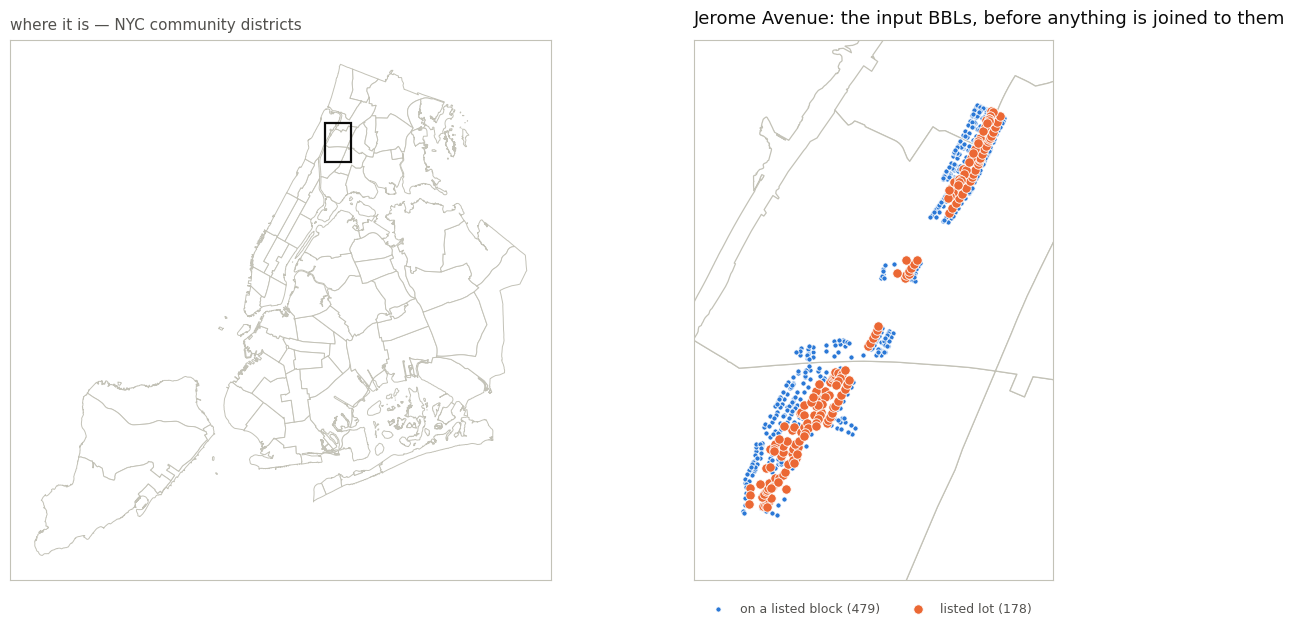

lots drawn: 657 of 659 | bbox: 40.8317..40.8650 N, -73.9272..-73.8980 W


In [9]:
lots, missing_input = resolve_inputs(input_bbls + listed_bbls, BORO_CODE)
lots["source"] = lots["source"].where(~lots["bbl"].isin(listed_bbls), "listed lot")
save_csv(lots, f"{OUT}_resolved_lots")

_ = map_bbls(lots, f"Jerome Avenue: the input BBLs, before anything is joined to them")

## 3. Scope the Housing Database to the study area
Two rungs: `scope_via = "bbl"` is a job filed under one of the individually listed lots,
`"bbl_block"` a job on a lot sitting on one of the 27 listed blocks.

The cost of the two choices, printed below: matching the 188 mapped BBLs exactly returns
~14 jobs — far too thin to read a per-year trend off, and it misses buildings that went
up beside the mapped lots on the same rezoned blocks. The blocks return ~101.

In [10]:
hdb = load_housingdb(HDB_PATH)
print("\nexact-BBL match on the 188 mapped lots would give:",
      int(hdb["BBL"].isin(listed_bbls).sum()), "jobs\n")

scoped = hdb_scope(hdb, input_bbls)

HousingDB rows: 81708 | distinct BBL: 68190 | distinct BIN: 71408 | completed: 66508

exact-BBL match on the 188 mapped lots would give: 14 jobs

scoped jobs: 101 | distinct BBL: 75 | distinct BIN: 79
  scope_via: {'bbl_block': 101}
  job types: {'New Building': 42, 'Alteration': 33, 'Demolition': 26}
  completed: 70 of 101


## 4. Have any of these BBLs been sunsetted?
A **sunsetted** BBL is one DOF has retired — split, merged, or converted to a condo — so
it no longer exists in current PLUTO. That matters because a retired BBL silently drops
out of any lot-keyed join.

For any BBL that is missing we follow the apportionment lineage: **`appbbl` sits on the
successor row and points back at the retired predecessor**. The answer lands in a **new
column, `pluto_current_bbl`**, and **the BIN is never touched** — which is what makes the
step safe, since every join from here on is keyed on BIN.

It fires **twice** here, and both cases are worth reading rather than skipping.

**`2028720148` → `2028727501`, filled.** Three independent sources agree:

| evidence | says |
|---|---|
| PLUTO `appbbl` | lot `2028727501` declares `2028720148` as the lot it was made from |
| OTI footprint, BIN `2129668` | `base_bbl = 2028720148` **and** `mappluto_bbl = 2028727501` — the footprint layer draws the same old→new link from a separate dataset |
| attributes | PLUTO `2028727501` = "1544 Shakespeare Avenue", built 2022, **116 units**; the HousingDB New Building job on `2028720148` = "1544 Shakespeare Avenue", **`ClassANet` 116** |

Address and unit count match across two unrelated sources, which is what makes this a
corroborated match rather than a plausible one. The story reads cleanly: two demolitions
completed 2019, a 116-unit building completed 2024, then a condo conversion — DOF retires
lot `0148` and issues condo billing lot `7501`. Same tax block, so the different-block
guard stays quiet.

**`2024890035`, not filled.** No successor declares it, so it is left alone rather than
guessed at. Its only job — 1240 River Avenue, 328 units — is still
`3. Permitted for Construction` with no `CompltYear`, so it contributes nothing to any
completed total below. Worth re-checking on a future run: when that building completes it
will need a successor BBL to be reachable by lot.

Run against the **188 mapped lots** the same audit finds nothing — DCP re-geocodes the
Housing Database every release, so its BBLs are already current-PLUTO BBLs, unlike a raw
DOB filing stamped with the BBL current at filing time. It is the wider block scope that
reaches the retired lots.

In [11]:
bins_before = scoped["BIN"].tolist()          # the claim this step must not break
status = bbl_status(scoped["BBL"].unique().tolist())
scoped = scoped.merge(status[["bbl", "pluto_current_bbl", "bbl_sunsetted"]],
                      left_on="BBL", right_on="bbl", how="left").drop(columns="bbl")
assert scoped["BIN"].tolist() == bins_before, "the audit changed a BIN — it must not"

save_csv(status, f"{OUT}_bbl_status")
_ = save_csv(scoped, f"{OUT}_scoped_jobs")

APPBBL successors: 1 genuine (0 self-references dropped, appbbl == bbl)
BBL sunsetting audit: 2 of 75 not in current PLUTO | successor found for 1
       bbl  in_current_pluto pluto_current_bbl successor_source  bbl_sunsetted
2024890035             False        2024890035             <NA>           True
2028720148             False        2028727501     pluto_appbbl           True
saved: (75, 5) -> C:\Users\arian\Documents\fable_housing\notebooks\jerome_ave_hdb_bbl_status.csv
saved: (101, 26) -> C:\Users\arian\Documents\fable_housing\notebooks\jerome_ave_hdb_scoped_jobs.csv


## 5. One row per BIN — including what was demolished
The grain is the **building**. Units and years come from **completed jobs only**, since a
filed or permitted job has not produced a unit yet.

Three columns here are new relative to the first version of this notebook, and the third
is the one that stops the first two being misread:

- **`demo_complt_year`** — the year a Demolition job on this BIN completed.
- **`demolished_post_rezone`** — whether that landed in the rezoning period.
- **`rebuilt_after_demo`** — whether a New Building *also* completed on the same BIN at or
  after the demolition.

That last one matters because a teardown followed by a new building on the same BIN is the
normal redevelopment pattern on a rezoned corridor — it is the mechanism the rezoning was
meant to trigger. So `demolished_post_rezone` on its own does **not** mean "this building
is gone", and the summary below splits the two.

In [12]:
bins = hdb_bin_table(scoped, REZONE_YEAR)

demo = bins[bins["demolished_post_rezone"]]
if len(demo):
    print(f"\ndemolished {REZONE_YEAR}+ ({len(demo)} BINs):")
    print(demo[["bin", "bbl", "address", "demo_complt_year", "hdb_nb_complt_year",
                "rebuilt_after_demo", "net_units"]].to_string(index=False))

BIN rows: 79 | sentinel BINs (kept & flagged): 0 | BINs under >1 BBL: 0
  net units (completed jobs): 2128
  demolished 2018+: 13 | of those, rebuilt on the same BIN: 9

demolished 2018+ (13 BINs):
    bin        bbl                      address  demo_complt_year  hdb_nb_complt_year  rebuilt_after_demo  net_units
2003100 2025060125           76 WEST 170 STREET            2022.0                 NaN               False       -2.0
2008159 2028480024         1677 TOWNSEND AVENUE            2021.0              2023.0                True       32.0
2008433 2028650134            1600 MACOMBS ROAD            2021.0                 NaN               False        0.0
2008659 2028720070            1438 JESUP AVENUE            2022.0                 NaN               False        5.0
2014087 2031870036           2351 WALTON AVENUE            2018.0              2023.0                True       59.0
2091246 2025060081 1256 REAR SHAKESPEARE AVENUE            2022.0                 NaN               

## 6. Footprint polygons — keyed on BIN, not BBL
Pulled **by BIN** so the sunsetting audit cannot affect them: whatever PLUTO says about
the lot underneath, the building still finds its polygon. Coverage is partial, and every
row records which geometry it got in `geom_source`.

In [13]:
bins = attach_footprints(bins)

footprints: 64 BINs | {'Constructed': 63, 'Alteration': 1}
geometry: {'oti_polygon': 64, 'hdb_point': 15}


## 7. Three construction dates, side by side
The sanity check the rest of the table rests on. Each row can now carry three
independently-sourced answers to "when was this built?":

| column | source | what it actually means |
|---|---|---|
| `pluto_yearbuilt` | PLUTO (assessor) | year built as recorded on the **lot** — shared by every building on a multi-building lot |
| `oti_construction_year` | OTI footprints | a survey observation of the structure |
| `hdb_nb_complt_year` | HousingDB (DOB) | the year DOB recorded the New Building job **complete** |

They disagree, and the disagreement is diagnostic rather than a defect. PLUTO writes `0`
for unknown (converted to blank here, or it reads as the year 0 in any comparison); its
lot-level value can describe a *different* building on the same lot; and a building
predating 2010 has no HousingDB job at all. Where all three agree, the row is solid.

In [14]:
bins = attach_pluto(bins, lots)

dates = ["pluto_yearbuilt", "oti_construction_year", "hdb_nb_complt_year"]
print("\nrows with each construction date:",
      {c: int(bins[c].notna().sum()) for c in dates}, "of", len(bins))
print("\nsample where all three exist:")
allthree = bins[bins[dates].notna().all(axis=1)]
print(allthree[["bin", "address"] + dates].head(12).to_string(index=False))

PLUTO yearbuilt attached to 69 of 79 BINs
  vs HousingDB New Building year, where both exist (n=28): agree exactly 0, within 2y 21, median gap 2y

rows with each construction date: {'pluto_yearbuilt': 69, 'oti_construction_year': 63, 'hdb_nb_complt_year': 29} of 79

sample where all three exist:
    bin                 address pluto_yearbuilt  oti_construction_year  hdb_nb_complt_year
2008159    1677 TOWNSEND AVENUE          2022.0                 2020.0              2023.0
2008287      1351 JEROME AVENUE          1990.0                 1990.0              2025.0
2014087      2351 WALTON AVENUE          2022.0                 1920.0              2023.0
2088424         29 EVELYN PLACE          2021.0                 2022.0              2022.0
2117719       1482 JESUP AVENUE          2011.0                 2011.0              2012.0
2118416         5 CLINTON PLACE          2007.0                 2007.0              2019.0
2119009       1480 JESUP AVENUE          2011.0                 20

## 8. Buildings built in the rezoning period, aggregated by year
`net_units` is Σ `ClassANet` across **all** job types, so the negative units a completed
demolition carries are subtracted — the true net change in permanent residential units,
not a gross build count.

Units and building counts are different measures on different scales, so they get stacked
panels sharing the x-axis rather than one chart with two y-scales.

Read the pre/post split with the construction cycle in mind: `CompltYear` is when a
building was *finished*, so a rezoning adopted in March 2018 cannot show up in completions
for roughly three to five years. The 2018 line marks the policy, not the point where the
bars should jump.

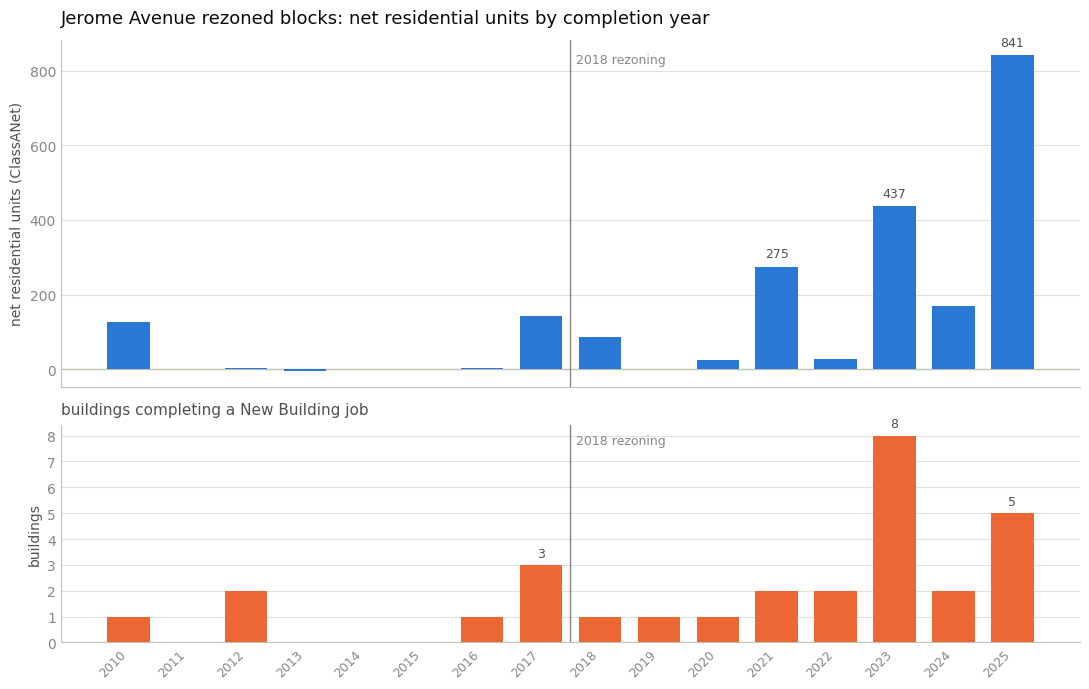

                                   pre-2018          2018+          total
net residential units                   269          1,859          2,128
  of which New Building                 280          1,756          2,036
  of which Demolition                   -11            -23            -34
buildings built (NB)                      7             22             29
buildings demolished                      5             13             18
completed jobs                           15             55             70
saved: (16, 8) -> C:\Users\arian\Documents\fable_housing\notebooks\jerome_ave_hdb_by_year.csv


In [15]:
by_year = year_chart(hdb_by_year(scoped, first=2010), REZONE_YEAR,
                     "Jerome Avenue rezoned blocks: net residential units by completion year")
save_csv(by_year.reset_index(), f"{OUT}_by_year")

completed = scoped[scoped["hdb_completed"] & (scoped["CompltYear"] >= 2010)]
assert by_year["net_units"].sum() == completed["ClassANet"].sum(), "chart total != job total"

## 9. The result map
Colour carries the era, shape carries the geometry source. Compare it against the §2
sanity map: the same footprint, now filled in with what was actually built.

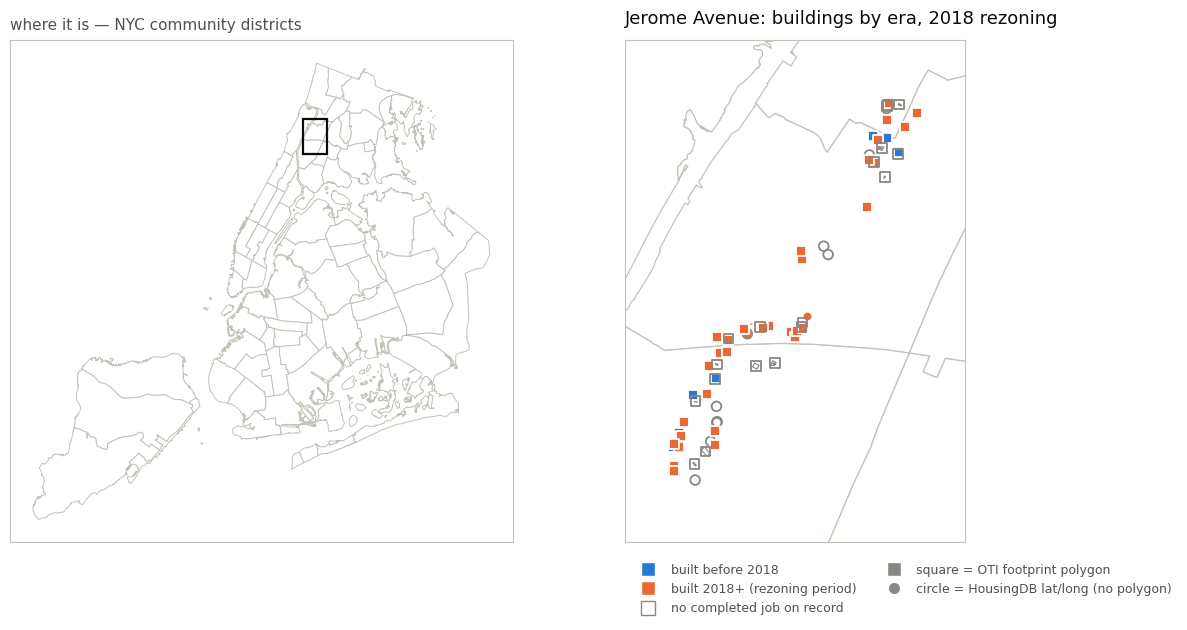

drawn: 64 polygons + 15 points = 79 of 79 BINs
by era: {'post': 40, 'no completed job': 28, 'pre': 11}


In [16]:
polys, pts = map_buildings(bins, REZONE_YEAR,
                           f"Jerome Avenue: buildings by era, {REZONE_YEAR} rezoning")

## 10. Save
The BIN table goes out twice — a CSV that stays a plain table (geometry as a WKT string)
and a GeoPackage with real EPSG:4326 polygons for QGIS / duckdb-spatial. Together with
the tables already written in §2, §4 and §8, every intermediate result is on disk.

In [17]:
cols = ["bin", "bbl", "pluto_current_bbl", "n_bbls", "scope_via", "address", "pluto_address",
        "lat", "lon", "geom_source",
        # the three construction dates
        "pluto_yearbuilt", "oti_construction_year", "hdb_nb_complt_year",
        "hdb_first_complt_year", "hdb_last_complt_year",
        # demolition
        "demo_complt_year", "demolished_post_rezone", "rebuilt_after_demo", "n_demolition",
        # jobs and units
        "n_jobs", "n_completed", "job_types", "n_new_building", "hdb_status",
        "net_units", "units_co", "pluto_unitsres", "pluto_bldgclass", "pluto_numbldgs",
        # provenance / geometry attributes
        "bin_is_sentinel", "base_bbl", "mappluto_bbl", "last_status_type", "feature_code",
        "height_roof", "ground_elevation", "shape_area", "doitt_id", "the_geom_wkt"]
bins["pluto_current_bbl"] = bins["bbl"].map(dict(zip(status["bbl"],
                                                     status["pluto_current_bbl"])))
bins = bins[[c for c in cols if c in bins.columns]]

save_csv(bins, f"{OUT}_bins")
save_gpkg(bins, f"{OUT}_bins")

post = bins[bins["hdb_nb_complt_year"] >= REZONE_YEAR]
print(f"\nbuildings with a New Building completion {REZONE_YEAR}+: {len(post)}"
      f" | net units on them: {int(post['net_units'].sum()):,}")
bins.drop(columns="the_geom_wkt").head()

saved: (79, 39) -> C:\Users\arian\Documents\fable_housing\notebooks\jerome_ave_hdb_bins.csv
saved: (64, 39) -> C:\Users\arian\Documents\fable_housing\notebooks\jerome_ave_hdb_bins.gpkg (15 rows had no polygon)

buildings with a New Building completion 2018+: 22 | net units on them: 1,737


,bin,bbl,pluto_current_bbl,n_bbls,scope_via,address,pluto_address,lat,lon,geom_source,pluto_yearbuilt,oti_construction_year,hdb_nb_complt_year,hdb_first_complt_year,hdb_last_complt_year,demo_complt_year,demolished_post_rezone,rebuilt_after_demo,n_demolition,n_jobs,n_completed,job_types,n_new_building,hdb_status,net_units,units_co,pluto_unitsres,pluto_bldgclass,pluto_numbldgs,bin_is_sentinel,base_bbl,mappluto_bbl,last_status_type,feature_code,height_roof,ground_elevation,shape_area,doitt_id
0,2003082,2025060044,2025060044,1,bbl_block,1263 EDWARD L GRANT HIGHWAY,1263 EDWARD L GRANT HWY,40.837348,-73.922690,oti_polygon,2002.0,2002.0,NaN,2022.0,2022.0,NaN,False,False,0,1,1.0,Alteration,0,5. Completed Construction,0.0,79.0,0.0,H4,1.0,False,2025060044,2025060044,Constructed,2100,25.290000,29.0,2447.578125,933155
1,2003100,2025060125,2025060125,1,bbl_block,76 WEST 170 STREET,WEST 170TH STREET,40.840095,-73.921850,hdb_point,2024.0,NaN,NaN,2022.0,2022.0,2022.0,True,False,1,1,1.0,Demolition,0,5. Completed Construction,-2.0,0.0,39.0,D7,1.0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2003110,2025060148,2025060148,1,bbl_block,67 WEST 169 STREET,67 WEST 169 STREET,40.839227,-73.922091,oti_polygon,1925.0,1925.0,NaN,2025.0,2025.0,NaN,False,False,0,1,1.0,Alteration,0,5. Completed Construction,4.0,8.0,8.0,C1,1.0,False,2025060148,2025060148,Constructed,2100,28.988977,80.0,132.691406,625766
3,2008140,2028460037,2028460037,1,bbl_block,1575 TOWNSEND AVENUE,1575 TOWNSEND AVENUE,40.843896,-73.914254,oti_polygon,1922.0,1922.0,NaN,NaN,NaN,NaN,False,False,0,1,0.0,Alteration,0,2. Approved Application,0.0,0.0,45.0,C7,2.0,False,2028460037,2028460037,Constructed,2100,60.770000,55.0,1250.886719,581942
4,2008159,2028480024,2028480024,1,bbl_block,1677 TOWNSEND AVENUE,1677 TOWNSEND AVENUE,40.845953,-73.912787,oti_polygon,2022.0,2020.0,2023.0,2021.0,2023.0,2021.0,True,True,1,2,2.0,Demolition; New Building,1,5. Completed Construction,32.0,35.0,35.0,D1,1.0,False,2028480024,2028480024,Constructed,2100,88.000000,39.0,544.144531,1299030
